In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/energy_household_consumption.csv')

print("Dataset Shape:", df.shape)

display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (1003, 7)


,Household_ID,Timestamp,Electricity_Consumption,Household_Size,Appliance_Ownership,Region,Weather
0,1001,2026-01-01 02:00:00,1.810,3,5,South,Hot
1,1001,2026-01-01 06:00:00,2.396,3,5,South,Hot
2,1001,2026-01-01 09:00:00,2.661,3,5,South,Warm
3,1001,2026-01-01 12:00:00,2.179,3,5,South,Hot
4,1001,2026-01-01 15:00:00,1.800,3,5,South,Warm



Column Names:
['Household_ID', 'Timestamp', 'Electricity_Consumption', 'Household_Size', 'Appliance_Ownership', 'Region', 'Weather']

Data Types:
Household_ID                 int64
Timestamp                   object
Electricity_Consumption    float64
Household_Size               int64
Appliance_Ownership          int64
Region                      object
Weather                     object
dtype: object

Missing Values:
Household_ID               0
Timestamp                  0
Electricity_Consumption    0
Household_Size             0
Appliance_Ownership        0
Region                     0
Weather                    2
dtype: int64

Duplicate Rows: 3


In [2]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Check invalid timestamps
print("Invalid timestamps:", df['Timestamp'].isna().sum())

# Check negative electricity consumption
print("Negative consumption values:",
      (df['Electricity_Consumption'] < 0).sum())

# Check invalid household sizes
print("Invalid household sizes:",
      (df['Household_Size'] <= 0).sum())

# Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Duplicate rows removed:", before - after)

# Fill missing Weather values with the most frequent value
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nFinal dataset shape:", df.shape)

display(df.head())

Invalid timestamps: 0
Negative consumption values: 0
Invalid household sizes: 0
Duplicate rows removed: 3

Missing values after cleaning:
Household_ID               0
Timestamp                  0
Electricity_Consumption    0
Household_Size             0
Appliance_Ownership        0
Region                     0
Weather                    0
dtype: int64

Final dataset shape: (1000, 7)


,Household_ID,Timestamp,Electricity_Consumption,Household_Size,Appliance_Ownership,Region,Weather
0,1001,2026-01-01 02:00:00,1.810,3,5,South,Hot
1,1001,2026-01-01 06:00:00,2.396,3,5,South,Hot
2,1001,2026-01-01 09:00:00,2.661,3,5,South,Warm
3,1001,2026-01-01 12:00:00,2.179,3,5,South,Hot
4,1001,2026-01-01 15:00:00,1.800,3,5,South,Warm


In [3]:
print("Minimum consumption:", df['Electricity_Consumption'].min())
print("Maximum consumption:", df['Electricity_Consumption'].max())

print("\nHousehold size:")
print(df['Household_Size'].value_counts().sort_index())

print("\nRegions:")
print(df['Region'].value_counts())

print("\nWeather:")
print(df['Weather'].value_counts())

Minimum consumption: 0.525
Maximum consumption: 12.592

Household size:
Household_Size
1    110
2    190
3    230
4    230
5    160
6     80
Name: count, dtype: int64

Regions:
Region
South    370
West     280
East     200
North    150
Name: count, dtype: int64

Weather:
Weather
Warm     403
Hot      376
Cool     152
Humid     69
Name: count, dtype: int64


In [4]:
# Descriptive statistics for numerical columns
print("Numerical Descriptive Statistics:")
display(df.describe())

# Average consumption
print("\nAverage Electricity Consumption:",
      round(df['Electricity_Consumption'].mean(), 2))

# Median consumption
print("Median Electricity Consumption:",
      round(df['Electricity_Consumption'].median(), 2))

# Consumption by household
household_summary = df.groupby('Household_ID').agg(
    Total_Consumption=('Electricity_Consumption', 'sum'),
    Average_Consumption=('Electricity_Consumption', 'mean'),
    Maximum_Consumption=('Electricity_Consumption', 'max'),
    Household_Size=('Household_Size', 'first'),
    Appliance_Ownership=('Appliance_Ownership', 'first'),
    Region=('Region', 'first')
).reset_index()

display(household_summary.head(10))

Numerical Descriptive Statistics:


,Household_ID,Timestamp,Electricity_Consumption,Household_Size,Appliance_Ownership
count,1000.000000,1000,1000.000000,1000.000000,1000.00000
mean,1050.500000,2026-01-06 02:29:59.999999744,3.083857,3.380000,7.86000
min,1001.000000,2026-01-01 02:00:00,0.525000,1.000000,3.00000
25%,1025.750000,2026-01-03 17:15:00,2.114000,2.000000,6.00000
50%,1050.500000,2026-01-06 00:30:00,2.812000,3.000000,8.00000
75%,1075.250000,2026-01-08 15:45:00,3.904250,4.000000,10.00000
max,1100.000000,2026-01-10 23:00:00,12.592000,6.000000,13.00000
std,28.880514,NaN,1.349660,1.441415,2.38035



Average Electricity Consumption: 3.08
Median Electricity Consumption: 2.81


,Household_ID,Total_Consumption,Average_Consumption,Maximum_Consumption,Household_Size,Appliance_Ownership,Region
0,1001,27.195,2.7195,3.957,3,5,South
1,1002,46.668,4.6668,6.666,6,11,East
2,1003,36.040,3.6040,5.235,4,10,West
3,1004,36.819,3.6819,4.758,4,9,South
4,1005,26.568,2.6568,3.938,2,9,North
5,1006,25.582,2.5582,3.680,2,8,East
6,1007,19.187,1.9187,2.537,1,7,West
7,1008,56.125,5.6125,12.592,5,9,South
8,1009,37.371,3.7371,5.603,4,10,North
9,1010,28.928,2.8928,4.785,4,9,West


In [5]:
size_summary = df.groupby('Household_Size')['Electricity_Consumption'].agg(
    ['count', 'mean', 'median', 'max']
).round(2)

print("Consumption by Household Size:")
display(size_summary)

Consumption by Household Size:


,count,mean,median,max
Household_Size,,,,
1,110,1.78,1.69,4.41
2,190,2.44,2.25,7.42
3,230,2.75,2.50,5.08
4,230,3.51,3.11,5.89
5,160,4.01,3.63,12.59
6,80,4.28,3.95,6.84


In [6]:
region_summary = df.groupby('Region')['Electricity_Consumption'].agg(
    ['count', 'mean', 'median', 'max']
).round(2)

print("Consumption by Region:")
display(region_summary)

Consumption by Region:


,count,mean,median,max
Region,,,,
East,200,3.26,2.97,6.67
North,150,2.92,2.69,6.43
South,370,3.15,2.86,12.59
West,280,2.97,2.72,7.42


In [7]:
weather_summary = df.groupby('Weather')['Electricity_Consumption'].agg(
    ['count', 'mean', 'median', 'max']
).round(2)

print("Consumption by Weather:")
display(weather_summary)

Consumption by Weather:


,count,mean,median,max
Weather,,,,
Cool,152,2.55,2.44,5.85
Hot,376,3.33,3.04,12.59
Humid,69,3.33,2.86,6.67
Warm,403,3.02,2.80,10.18


In [8]:
# Create time-based features
df['Date'] = df['Timestamp'].dt.date
df['Month'] = df['Timestamp'].dt.month
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.day_name()

# Define peak hours: 6 PM to 10 PM
df['Peak_Hour'] = df['Hour'].between(18, 22)

print("Time features created successfully.")

display(df[['Timestamp', 'Date', 'Month', 'Hour',
            'Day_of_Week', 'Peak_Hour']].head(10))

Time features created successfully.


,Timestamp,Date,Month,Hour,Day_of_Week,Peak_Hour
0,2026-01-01 02:00:00,2026-01-01,1,2,Thursday,False
1,2026-01-01 06:00:00,2026-01-01,1,6,Thursday,False
2,2026-01-01 09:00:00,2026-01-01,1,9,Thursday,False
3,2026-01-01 12:00:00,2026-01-01,1,12,Thursday,False
4,2026-01-01 15:00:00,2026-01-01,1,15,Thursday,False
5,2026-01-01 18:00:00,2026-01-01,1,18,Thursday,True
6,2026-01-01 19:00:00,2026-01-01,1,19,Thursday,True
7,2026-01-01 20:00:00,2026-01-01,1,20,Thursday,True
8,2026-01-01 21:00:00,2026-01-01,1,21,Thursday,True
9,2026-01-01 23:00:00,2026-01-01,1,23,Thursday,False


In [9]:
hourly_consumption = df.groupby('Hour')['Electricity_Consumption'].mean().round(2)

print("Average Electricity Consumption by Hour:")
display(hourly_consumption)

Average Electricity Consumption by Hour:


,Electricity_Consumption
Hour,
2,2.18
6,2.28
9,3.16
12,2.27
15,2.19
18,4.05
19,4.21
20,4.16
21,4.11


In [10]:
peak_summary = df.groupby('Peak_Hour')['Electricity_Consumption'].agg(
    ['count', 'mean', 'median', 'max']
).round(2)

print("Peak vs Non-Peak Consumption:")
display(peak_summary)

Peak vs Non-Peak Consumption:


,count,mean,median,max
Peak_Hour,,,,
False,600,2.38,2.33,5.13
True,400,4.13,4.05,12.59


In [11]:
highest_hour = hourly_consumption.idxmax()
highest_value = hourly_consumption.max()

print("Highest Consumption Hour:", highest_hour)
print("Average Consumption:", highest_value)

Highest Consumption Hour: 19
Average Consumption: 4.21


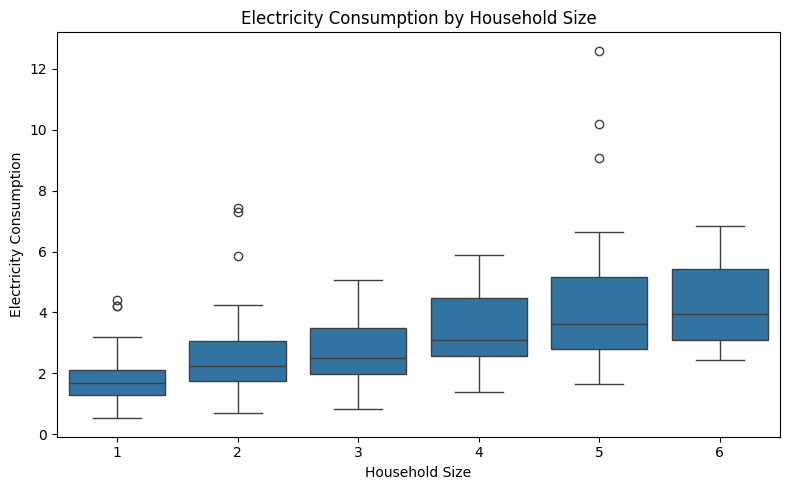

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Household_Size',
    y='Electricity_Consumption'
)

plt.title('Electricity Consumption by Household Size')
plt.xlabel('Household Size')
plt.ylabel('Electricity Consumption')
plt.tight_layout()
plt.show()

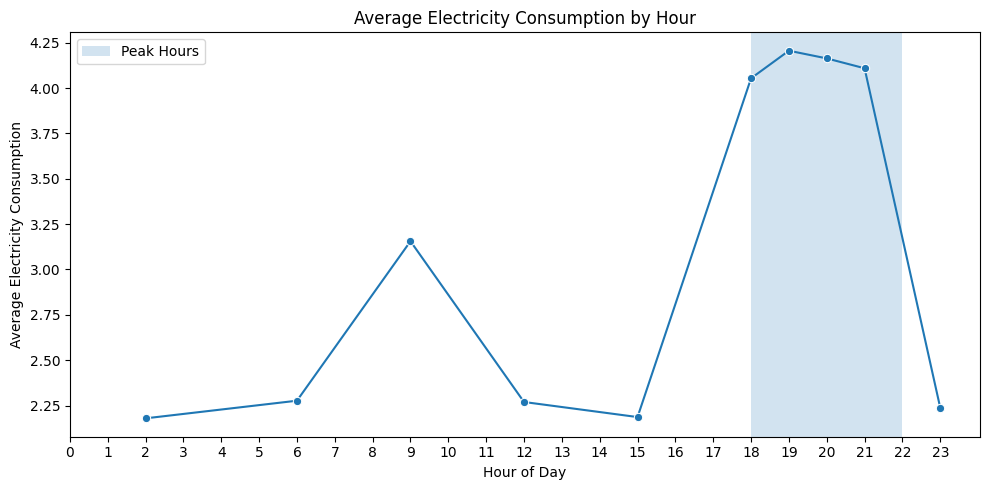

In [13]:
hourly_avg = df.groupby('Hour')['Electricity_Consumption'].mean().reset_index()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_avg,
    x='Hour',
    y='Electricity_Consumption',
    marker='o'
)

plt.axvspan(18, 22, alpha=0.2, label='Peak Hours')

plt.title('Average Electricity Consumption by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Electricity Consumption')
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

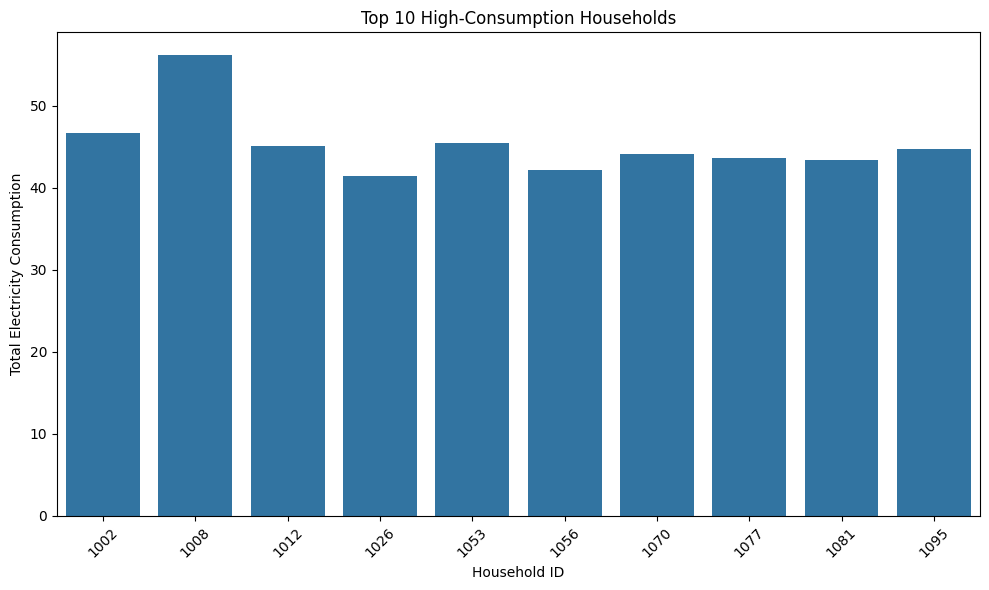

In [14]:
top_10 = household_summary.sort_values(
    'Total_Consumption',
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10,
    x='Household_ID',
    y='Total_Consumption'
)

plt.title('Top 10 High-Consumption Households')
plt.xlabel('Household ID')
plt.ylabel('Total Electricity Consumption')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
display(
    top_10[
        ['Household_ID',
         'Total_Consumption',
         'Average_Consumption',
         'Household_Size',
         'Appliance_Ownership',
         'Region']
    ]
)

,Household_ID,Total_Consumption,Average_Consumption,Household_Size,Appliance_Ownership,Region
7,1008,56.125,5.6125,5,9,South
1,1002,46.668,4.6668,6,11,East
52,1053,45.432,4.5432,6,11,East
11,1012,45.044,4.5044,6,10,South
94,1095,44.671,4.4671,5,12,East
69,1070,44.132,4.4132,6,8,South
76,1077,43.578,4.3578,5,11,West
80,1081,43.348,4.3348,5,12,East
55,1056,42.090,4.2090,6,8,South
25,1026,41.383,4.1383,5,10,East


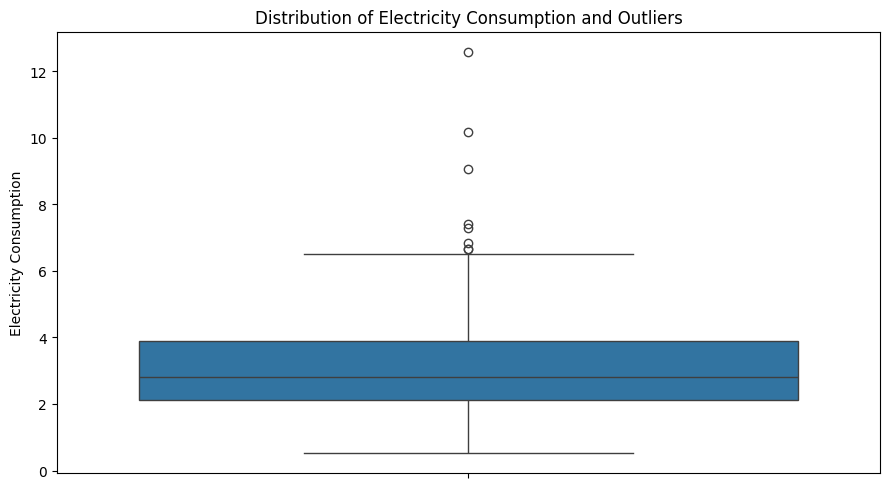

In [16]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    y=df['Electricity_Consumption']
)

plt.title('Distribution of Electricity Consumption and Outliers')
plt.ylabel('Electricity Consumption')
plt.tight_layout()
plt.show()

In [17]:
Q1 = df['Electricity_Consumption'].quantile(0.25)
Q3 = df['Electricity_Consumption'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['Electricity_Consumption'] < lower_limit) |
    (df['Electricity_Consumption'] > upper_limit)
]

print("Q1:", round(Q1, 3))
print("Q3:", round(Q3, 3))
print("IQR:", round(IQR, 3))
print("Lower Limit:", round(lower_limit, 3))
print("Upper Limit:", round(upper_limit, 3))
print("Number of unusual readings:", len(outliers))

Q1: 2.114
Q3: 3.904
IQR: 1.79
Lower Limit: -0.571
Upper Limit: 6.59
Number of unusual readings: 8


In [18]:
display(
    outliers[
        ['Household_ID',
         'Timestamp',
         'Electricity_Consumption',
         'Household_Size',
         'Appliance_Ownership',
         'Region',
         'Weather']
    ].sort_values(
        'Electricity_Consumption',
        ascending=False
    ).head(20)
)

,Household_ID,Timestamp,Electricity_Consumption,Household_Size,Appliance_Ownership,Region,Weather
78,1008,2026-01-08 21:00:00,12.592,5,9,South,Hot
76,1008,2026-01-08 19:00:00,10.182,5,9,South,Warm
77,1008,2026-01-08 20:00:00,9.070,5,9,South,Warm
318,1032,2026-01-02 21:00:00,7.418,2,7,West,Hot
316,1032,2026-01-02 19:00:00,7.303,2,7,West,Hot
115,1012,2026-01-02 18:00:00,6.836,6,10,South,Hot
18,1002,2026-01-02 21:00:00,6.666,6,11,East,Humid
945,1095,2026-01-05 18:00:00,6.653,5,12,East,Hot


In [19]:
household_features = df.groupby('Household_ID').agg(
    Average_Consumption=('Electricity_Consumption', 'mean'),
    Total_Consumption=('Electricity_Consumption', 'sum'),
    Maximum_Consumption=('Electricity_Consumption', 'max'),
    Household_Size=('Household_Size', 'first'),
    Appliance_Ownership=('Appliance_Ownership', 'first'),
    Region=('Region', 'first')
).reset_index()

display(household_features.head())

,Household_ID,Average_Consumption,Total_Consumption,Maximum_Consumption,Household_Size,Appliance_Ownership,Region
0,1001,2.7195,27.195,3.957,3,5,South
1,1002,4.6668,46.668,6.666,6,11,East
2,1003,3.6040,36.040,5.235,4,10,West
3,1004,3.6819,36.819,4.758,4,9,South
4,1005,2.6568,26.568,3.938,2,9,North


In [20]:
low_threshold = household_features['Average_Consumption'].quantile(0.33)
high_threshold = household_features['Average_Consumption'].quantile(0.67)

def classify_consumption(value):
    if value <= low_threshold:
        return 'Low Consumption'
    elif value <= high_threshold:
        return 'Medium Consumption'
    else:
        return 'High Consumption'

household_features['Consumption_Segment'] = (
    household_features['Average_Consumption']
    .apply(classify_consumption)
)

print("Low threshold:", round(low_threshold, 2))
print("High threshold:", round(high_threshold, 2))

display(
    household_features[
        ['Household_ID',
         'Average_Consumption',
         'Household_Size',
         'Appliance_Ownership',
         'Region',
         'Consumption_Segment']
    ].head(15)
)

Low threshold: 2.6
High threshold: 3.52


,Household_ID,Average_Consumption,Household_Size,Appliance_Ownership,Region,Consumption_Segment
0,1001,2.7195,3,5,South,Medium Consumption
1,1002,4.6668,6,11,East,High Consumption
2,1003,3.6040,4,10,West,High Consumption
3,1004,3.6819,4,9,South,High Consumption
4,1005,2.6568,2,9,North,Medium Consumption
5,1006,2.5582,2,8,East,Low Consumption
6,1007,1.9187,1,7,West,Low Consumption
7,1008,5.6125,5,9,South,High Consumption
8,1009,3.7371,4,10,North,High Consumption
9,1010,2.8928,4,9,West,Medium Consumption


In [21]:
segment_counts = household_features['Consumption_Segment'].value_counts()

print("Household Segments:")
display(segment_counts)

Household Segments:


,count
Consumption_Segment,
Medium Consumption,34
High Consumption,33
Low Consumption,33


In [22]:
segment_summary = household_features.groupby(
    'Consumption_Segment'
).agg(
    Households=('Household_ID', 'count'),
    Average_Consumption=('Average_Consumption', 'mean'),
    Average_Household_Size=('Household_Size', 'mean'),
    Average_Appliances=('Appliance_Ownership', 'mean')
).round(2)

display(segment_summary)

,Households,Average_Consumption,Average_Household_Size,Average_Appliances
Consumption_Segment,,,,
High Consumption,33,4.03,4.94,9.88
Low Consumption,33,2.14,1.91,5.61
Medium Consumption,34,3.08,3.29,8.09


In [23]:
# Use the 75th percentile as the high-consumption threshold
high_consumption_threshold = household_features['Average_Consumption'].quantile(0.75)

household_features['High_Consumption'] = (
    household_features['Average_Consumption'] >= high_consumption_threshold
).astype(int)

print("High-consumption threshold:",
      round(high_consumption_threshold, 2))

print("\nTarget distribution:")
print(household_features['High_Consumption'].value_counts())

display(
    household_features[
        ['Household_ID',
         'Average_Consumption',
         'High_Consumption']
    ].head(10)
)

High-consumption threshold: 3.74

Target distribution:
High_Consumption
0    75
1    25
Name: count, dtype: int64


,Household_ID,Average_Consumption,High_Consumption
0,1001,2.7195,0
1,1002,4.6668,1
2,1003,3.6040,0
3,1004,3.6819,0
4,1005,2.6568,0
5,1006,2.5582,0
6,1007,1.9187,0
7,1008,5.6125,1
8,1009,3.7371,0
9,1010,2.8928,0


In [24]:
peak_features = df.groupby('Household_ID').agg(
    Peak_Average_Consumption=(
        'Electricity_Consumption',
        lambda x: x[df.loc[x.index, 'Peak_Hour']].mean()
    )
).reset_index()

household_features = household_features.merge(
    peak_features,
    on='Household_ID',
    how='left'
)

household_features['Peak_Ratio'] = (
    household_features['Peak_Average_Consumption'] /
    household_features['Average_Consumption']
)

display(household_features.head())

,Household_ID,Average_Consumption,Total_Consumption,Maximum_Consumption,Household_Size,Appliance_Ownership,Region,Consumption_Segment,High_Consumption,Peak_Average_Consumption,Peak_Ratio
0,1001,2.7195,27.195,3.957,3,5,South,Medium Consumption,0,3.56375,1.310443
1,1002,4.6668,46.668,6.666,6,11,East,High Consumption,1,6.12325,1.312088
2,1003,3.6040,36.040,5.235,4,10,West,High Consumption,0,4.96925,1.378815
3,1004,3.6819,36.819,4.758,4,9,South,High Consumption,0,4.59675,1.248472
4,1005,2.6568,26.568,3.938,2,9,North,Medium Consumption,0,3.17875,1.196458


In [25]:
print("KNN Dataset Shape:", household_features.shape)

print("\nColumns:")
print(household_features.columns.tolist())

print("\nMissing values:")
print(household_features.isnull().sum())

KNN Dataset Shape: (100, 11)

Columns:
['Household_ID', 'Average_Consumption', 'Total_Consumption', 'Maximum_Consumption', 'Household_Size', 'Appliance_Ownership', 'Region', 'Consumption_Segment', 'High_Consumption', 'Peak_Average_Consumption', 'Peak_Ratio']

Missing values:
Household_ID                0
Average_Consumption         0
Total_Consumption           0
Maximum_Consumption         0
Household_Size              0
Appliance_Ownership         0
Region                      0
Consumption_Segment         0
High_Consumption            0
Peak_Average_Consumption    0
Peak_Ratio                  0
dtype: int64


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features for KNN
X = household_features[
    [
        'Household_Size',
        'Appliance_Ownership',
        'Peak_Average_Consumption',
        'Peak_Ratio',
        'Region'
    ]
].copy()

# Target
y = household_features['High_Consumption']

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,Household_Size,Appliance_Ownership,Peak_Average_Consumption,Peak_Ratio,Region
0,3,5,3.56375,1.310443,South
1,6,11,6.12325,1.312088,East
2,4,10,4.96925,1.378815,West
3,4,9,4.59675,1.248472,South
4,2,9,3.17875,1.196458,North



Target:


,High_Consumption
0,0
1,1
2,0
3,0
4,0


In [27]:
X = pd.get_dummies(
    X,
    columns=['Region'],
    drop_first=True
)

print("Encoded features:")
display(X.head())

Encoded features:


,Household_Size,Appliance_Ownership,Peak_Average_Consumption,Peak_Ratio,Region_North,Region_South,Region_West
0,3,5,3.56375,1.310443,False,True,False
1,6,11,6.12325,1.312088,False,False,False
2,4,10,4.96925,1.378815,False,False,True
3,4,9,4.59675,1.248472,False,True,False
4,2,9,3.17875,1.196458,True,False,False


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 80
Testing samples: 20


In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

# Display results
k_results = pd.DataFrame({
    'K': list(k_values),
    'Accuracy': accuracies
})

display(k_results)

,K,Accuracy
0,1,1.00
1,2,0.95
2,3,0.95
3,4,0.95
4,5,0.95
5,6,0.95
6,7,0.90
7,8,0.90
8,9,0.90
9,10,0.95


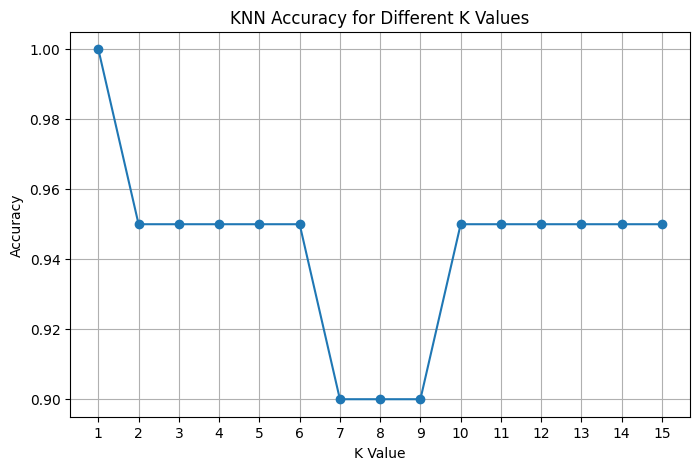

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.title('KNN Accuracy for Different K Values')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Test K values
k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

# Create results table
k_results = pd.DataFrame({
    'K': list(k_values),
    'Accuracy': accuracies
})

display(k_results)

# Find best K
best_index = np.argmax(accuracies)
best_k = list(k_values)[best_index]
best_accuracy = accuracies[best_index]

print("Best K:", best_k)
print("Best Accuracy:", round(best_accuracy, 4))

# Train final KNN model
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train_scaled, y_train)

print("Final KNN model trained successfully!")

,K,Accuracy
0,1,1.00
1,2,0.95
2,3,0.95
3,4,0.95
4,5,0.95
5,6,0.95
6,7,0.90
7,8,0.90
8,9,0.90
9,10,0.95


Best K: 1
Best Accuracy: 1.0
Final KNN model trained successfully!


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Make predictions using final KNN model
y_pred = final_knn.predict(X_test_scaled)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("KNN MODEL EVALUATION")
print("--------------------")
print("Best K:", best_k)
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Normal Consumption', 'High Consumption'],
    zero_division=0
))

KNN MODEL EVALUATION
--------------------
Best K: 1
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0

Classification Report:
                    precision    recall  f1-score   support

Normal Consumption       1.00      1.00      1.00        15
  High Consumption       1.00      1.00      1.00         5

          accuracy                           1.00        20
         macro avg       1.00      1.00      1.00        20
      weighted avg       1.00      1.00      1.00        20



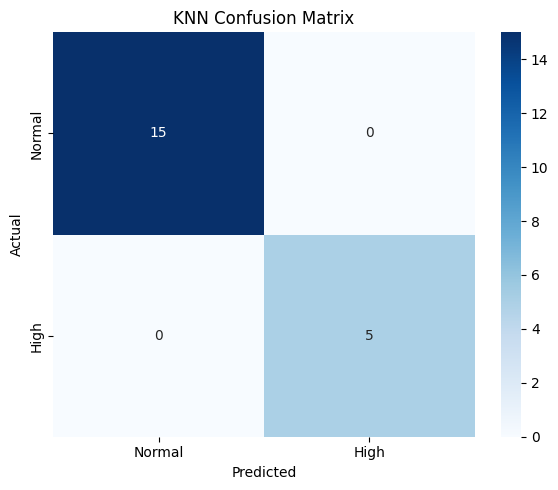

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'High'],
    yticklabels=['Normal', 'High']
)

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [36]:
# Top consumption household
top_household = household_features.loc[
    household_features['Average_Consumption'].idxmax()
]

# Highest household size consumption
highest_size = size_summary['mean'].idxmax()

# Highest consuming region
highest_region = region_summary['mean'].idxmax()

# Highest consuming weather condition
highest_weather = weather_summary['mean'].idxmax()

# Peak hour
peak_hour = hourly_consumption.idxmax()

# Number of high-consumption households
high_count = household_features['High_Consumption'].sum()

# Number of unusual readings
unusual_count = len(outliers)

print("FINAL PROJECT SUMMARY")
print("=" * 50)

print(f"Total Households: {household_features['Household_ID'].nunique()}")
print(f"Average Electricity Consumption: {df['Electricity_Consumption'].mean():.2f}")
print(f"Highest Average-Consumption Household: {top_household['Household_ID']}")
print(f"Highest Average Consumption: {top_household['Average_Consumption']:.2f}")
print(f"Highest Consuming Household Size: {highest_size}")
print(f"Highest Consuming Region: {highest_region}")
print(f"Highest Consumption Weather: {highest_weather}")
print(f"Peak Consumption Hour: {peak_hour}:00")
print(f"High-Consumption Households: {high_count}")
print(f"Unusual Consumption Readings: {unusual_count}")
print(f"Best K for KNN: {best_k}")
print(f"KNN Accuracy: {accuracy:.2%}")
print(f"KNN Precision: {precision:.2%}")
print(f"KNN Recall: {recall:.2%}")
print(f"KNN F1-Score: {f1:.2%}")

FINAL PROJECT SUMMARY
Total Households: 100
Average Electricity Consumption: 3.08
Highest Average-Consumption Household: 1008
Highest Average Consumption: 5.61
Highest Consuming Household Size: 6
Highest Consuming Region: East
Highest Consumption Weather: Hot
Peak Consumption Hour: 19:00
High-Consumption Households: 25
Unusual Consumption Readings: 8
Best K for KNN: 1
KNN Accuracy: 100.00%
KNN Precision: 100.00%
KNN Recall: 100.00%
KNN F1-Score: 100.00%
